In [3]:
!pip install -q seaborn aeon

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [17]:
import sqlite3
import pandas as pd
import numpy as np
from deepsig import aso
from tqdm.auto import tqdm
import os
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [20]:
db_path = "../results.db"

conn = sqlite3.connect(db_path)
df = pd.read_sql(f"""
SELECT 
    dataset,
    model,
    AVG(test_acc)     AS avg_test_acc,
    AVG(test_rmse)    AS avg_test_rmse,
    AVG(test_f1_macro) AS avg_test_f1_macro,
    AVG(inference_duration) AS avg_inference_duration
FROM final_results
GROUP BY dataset, model;

""", conn)
conn.close()

# Convert compute to ms/event
test_sizes = {
    "synthea": 433624 // 10,
    "crypto_transactions": 20832338 // 10,
    "earthquake": 91584 // 10,
    "volcano_easytpp": 8840 // 10,
    "taxi_easytpp": 74078 // 10,
    "taxi_nyc_neighborhoods": 62089613 // 10,
    "stackoverflow": 4361540 // 10,
    "retweet_easytpp": 2610102 // 10,
    "memetrac": 28611897 // 10,
    "wikipedia": 5920802 // 10,
    "amazon_easytpp": 413420 // 10,
    "taobao_easytpp": 113410 // 10,
    "human_activity": 6449 // 10,
    "mooc": 411749 // 10,
    "spiketrains": 842941 // 10,
    "911": 663522 // 10,
    "hawkes_1": 613058 // 10,
    "hawkes_dependent": 100829 // 10,
}

def to_ms_per_sample(row):
    test_n = test_sizes[row["dataset"]]
    return (row["avg_inference_duration"] * 1000) / test_n

df["ms_per_sample"] = df.apply(to_ms_per_sample, axis=1)

df

,dataset,model,avg_test_acc,avg_test_rmse,avg_test_f1_macro,avg_inference_duration,ms_per_sample
0,911,NHP,0.571863,0.124601,0.300679,15.001455,0.226089
1,amazon_easytpp,NHP,0.288556,0.535575,0.058388,7.358055,0.177980
2,earthquake,NHP,0.684580,6.993969,0.205279,18.185716,1.985774
3,hawkes_1,NHP,1.000000,2.826915,1.000000,2.668130,0.043522
4,hawkes_dependent,NHP,0.592248,7.351984,0.381715,9.660429,0.958186
5,human_activity,NHP,0.484028,1.304093,0.081181,2.020541,3.137486
6,mooc,NHP,0.302136,37.237770,0.166060,10.312338,0.250458
7,mooc,THP,0.078535,40.984266,0.011858,1.786722,0.043394
8,retweet_easytpp,THP,0.394844,65768.755821,0.188853,3.644392,0.013963
9,spiketrains,THP,0.487437,0.001345,0.072823,1.830408,0.021715


In [22]:
import pandas as pd
import numpy as np

EPS = 1e-5

def compute_normalized_scores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    metrics = {
        "avg_test_acc": "higher",
        "avg_test_rmse": "lower",
        # "avg_test_f1_macro": "higher",
        "ms_per_sample": "lower"
    }

    results = []
    valid_metrics_by_dataset = {}

    all_models = sorted(df["model"].unique())
    all_datasets = sorted(df["dataset"].unique())

    for dataset, g in df.groupby("dataset"):
        g = g.copy()
        norm_scores = {}
        valid_metrics = []

        for metric, direction in metrics.items():
            vals = g[metric]

            # skip constant 1.0 acc/f1 datasets
            if metric in ["avg_test_acc", "avg_test_f1_macro"] and np.allclose(vals, 1.0):
                continue

            valid_metrics.append(metric)

            if direction == "higher":
                topline = vals.max()
                baseline = vals.median()
                denom = max(topline - baseline, EPS)
                score = (topline - vals) / denom
            else:
                topline = vals.min()
                baseline = vals.median()
                denom = max(baseline - topline, EPS)
                score = (vals - topline) / denom

            norm_scores[metric] = score.clip(0, 1)

        valid_metrics_by_dataset[dataset] = valid_metrics

        for i, row in g.iterrows():
            entry = {
                "dataset": dataset,
                "model": row["model"],
            }
            for m in valid_metrics:
                entry[m] = norm_scores[m].loc[i]
            results.append(entry)

    norm_df = pd.DataFrame(results)

    # full dataset x model grid
    full_index = pd.MultiIndex.from_product(
        [all_datasets, all_models],
        names=["dataset", "model"]
    )
    norm_df = norm_df.set_index(["dataset", "model"]).reindex(full_index).reset_index()

    # fill missing evaluations with worst possible normalized value = 1
    # but only for metrics that are valid for that dataset
    for dataset, valid_metrics in valid_metrics_by_dataset.items():
        mask = norm_df["dataset"] == dataset
        for metric in valid_metrics:
            norm_df.loc[mask, metric] = norm_df.loc[mask, metric].fillna(1.0)

    # average across datasets per model
    overall = (
        norm_df
        .groupby("model", as_index=False)
        .mean(numeric_only=True)
    )
    overall["dataset"] = "Overall (Norm)"

    # align columns to original df
    cols = df.columns
    for col in cols:
        if col not in overall.columns:
            overall[col] = np.nan
    overall = overall[cols]

    return pd.concat([df, overall], ignore_index=True)

df_ = compute_normalized_scores(df)
df_["objective"] = (df_["avg_test_acc"] - 0.2 * df_["avg_test_rmse"]) / 1.2
df_.loc[df_["dataset"] != "Overall (Norm)", "objective"] = 1
df = df_
df.tail(9)

,dataset,model,avg_test_acc,avg_test_rmse,avg_test_f1_macro,avg_inference_duration,ms_per_sample,objective
9,spiketrains,THP,0.487437,0.001345,0.072823,1.830408,0.021715,1.000000
10,stackoverflow,THP,0.000978,2207.111028,0.000059,13.074426,0.029977,1.000000
11,synthea,THP,0.008940,29216.396318,0.000546,2.550747,0.058824,1.000000
12,taobao_easytpp,THP,0.583479,0.133520,0.431501,1.733521,0.152854,1.000000
13,taxi_easytpp,THP,0.898524,0.398855,0.397557,1.945675,0.262681,1.000000
14,taxi_nyc_neighborhoods,THP,0.117562,1.241429,0.023746,276.051877,0.044460,1.000000
15,volcano_easytpp,THP,1.000000,41643.808752,1.000000,1.624661,1.837852,1.000000
16,Overall (Norm),NHP,0.538462,0.533333,NaN,NaN,0.600000,0.359829
17,Overall (Norm),THP,0.461538,0.466667,NaN,NaN,0.400000,0.306838


In [12]:
dataset_names = {
    "911": "911",
    "amazon_easytpp": "Amazon",
    "crypto_transactions": "Transactions",
    "earthquake": "Earthquakes",
    "hawkes_1": "Hawkes 1",
    "hawkes_dependent": "Hawkes Dep",
    "human_activity": "Human Activity",
    "memetrack": "MemeTrack",
    "mooc": "MOOC",
    "retweet_easytpp": "Retweets",
    "spiketrains": "Neural Spikes",
    "stackoverflow": "Stack Overflow",
    "synthea": "Synthea",
    "taobao_easytpp": "Taobao",
    "taxi_easytpp": "Taxi Boroughs",
    "taxi_nyc_neighborhoods": "Taxi NBHD",
    "volcano_easytpp": "Volcano",
    "wikipedia": "Wikipedia",
}

model_names = {
    "IntensityFree": "IFTPP",
    "RMTPP": "RMTPP",
    "SAHP": "SAHP",
    "ODETPP": "ODETPP",
    "S2P2": "S2P2",
    "THP": "THP",
    "NHP": "NHP",
}

# Raw Results

In [13]:
from __future__ import annotations

from typing import Iterable, Mapping, Sequence

import numpy as np
import pandas as pd
from matplotlib import cm


def df_to_latex_booktabs_transposed(
    df: pd.DataFrame,
    *,
    dataset_col: str = "dataset",
    model_col: str = "model",
    metric_cols: Sequence[str] = ("avg_test_acc", "avg_test_rmse", "avg_test_f1_macro", "objective"),
    metric_display_names: Mapping[str, str] | None = None,
    dataset_display_names: Mapping[str, str] | None = None,
    model_display_names: Mapping[str, str] | None = None,
    lower_is_better: Iterable[str] = ("avg_test_rmse",),
    float_fmt: str = ".3f",
    cmap_name: str = "magma",
    caption: str | None = None,
    label: str | None = None,
    table_env: bool = True,
    center: bool = True,
    na_rep: str = "--",
    zero_variation_tol: float = 1e-12,
    font_size_cmd: str = r"\scriptsize",
    arraystretch: float = 0.92,
    tabcolsep_pt: float = 3.2,
    tabrowsep_pt: float = 3.2,
    use_resizebox: bool = True,
    resize_to: str = r"\linewidth",
    dataset_vertical_rules: bool = False,
) -> str:
    """
    Layout:
        rows    = metrics grouped by dataset
        columns = models

    Features:
    - leftmost column: dataset name via \\multirow
    - second column: metric name
    - model columns on the right
    - remove metric rows with zero variation across models within a dataset
    - magma heatmap coloring per row
    - bold best value in each row
    - missing values shown as black cells with white '--'

    Required LaTeX packages:
        \\usepackage{booktabs}
        \\usepackage[table]{xcolor}
        \\usepackage{multirow}
        \\usepackage{array}
        \\usepackage{graphicx}   % if use_resizebox=True
        \\usepackage{colortbl}
    """
    required = {dataset_col, model_col, *metric_cols}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    metric_display_names = metric_display_names or {
        "avg_test_acc": "Acc",
        "avg_test_rmse": "RMSE",
        "avg_test_f1_macro": "F1",
        "objective": "Objective"
    }
    dataset_display_names = dataset_display_names or {}
    model_display_names = model_display_names or {}
    lower_is_better = set(lower_is_better)

    def latex_escape(text: object) -> str:
        s = str(text)
        replacements = {
            "&": r"\&",
            "%": r"\%",
            "$": r"\$",
            "#": r"\#",
            "_": r"\_",
            "{": r"\{",
            "}": r"\}",
            "~": r"\textasciitilde{}",
            "^": r"\textasciicircum{}",
            "\\": r"\textbackslash{}",
        }
        return "".join(replacements.get(ch, ch) for ch in s)

    def fmt(x: float) -> str:
        return format(float(x), float_fmt)

    def rgba_to_rgb255(rgba: tuple[float, float, float, float]) -> tuple[int, int, int]:
        r, g, b, _ = rgba
        return (
            int(round(255 * r)),
            int(round(255 * g)),
            int(round(255 * b)),
        )

    def luminance(rgb: tuple[int, int, int]) -> float:
        r, g, b = rgb
        return (0.2126 * r + 0.7152 * g + 0.0722 * b) / 255.0

    def text_color_for_bg(rgb: tuple[int, int, int]) -> str:
        return "black" if luminance(rgb) > 0.55 else "white"

    def best_mask(series: pd.Series, minimize: bool) -> pd.Series:
        valid = series.dropna()
        if valid.empty:
            return pd.Series(False, index=series.index)
        target = valid.min() if minimize else valid.max()
        return series.eq(target)

    def scores_01(series: pd.Series, minimize: bool) -> pd.Series:
        s = series.astype(float)
        valid = s.dropna()
        if valid.empty:
            return pd.Series(np.nan, index=s.index)

        vmin = valid.min()
        vmax = valid.max()

        if np.isclose(vmin, vmax, atol=zero_variation_tol):
            return pd.Series(0.5, index=s.index)

        if minimize:
            out = (vmax - s) / (vmax - vmin)
        else:
            out = (s - vmin) / (vmax - vmin)
        return out.clip(0.0, 1.0)

    def cell_tex(value: float | None, score: float | None, is_best: bool) -> str:
        if pd.isna(value):
            return rf"\cellcolor[HTML]{{000000}}\textcolor{{white}}{{{na_rep}}}"

        text = fmt(value)
        if is_best:
            text = rf"\textbf{{{text}}}"

        if score is None or pd.isna(score):
            return text

        rgb = rgba_to_rgb255(cmap(score))
        html = f"{rgb[0]:02X}{rgb[1]:02X}{rgb[2]:02X}"
        fg = text_color_for_bg(rgb)
        return rf"\cellcolor[HTML]{{{html}}}\textcolor{{{fg}}}{{{text}}}"

    # pivot: rows=(dataset, metric), cols=models
    pivot = (
        df[[dataset_col, model_col, *metric_cols]]
        .melt(
            id_vars=[dataset_col, model_col],
            value_vars=list(metric_cols),
            var_name="metric",
            value_name="value",
        )
        .pivot_table(
            index=[dataset_col, "metric"],
            columns=model_col,
            values="value",
            aggfunc="mean",
        )
    )

    dataset_order = list(dict.fromkeys(df[dataset_col].tolist()))
    model_order = list(dict.fromkeys(df[model_col].tolist()))
    pivot = pivot.reindex(columns=[m for m in model_order if m in pivot.columns])

    # Remove metric rows with zero variation across models within each dataset
    kept_rows: list[tuple[str, str]] = []
    kept_metrics_by_dataset: dict[str, list[str]] = {}

    for ds in dataset_order:
        metrics_here: list[str] = []
        for metric in metric_cols:
            idx = (ds, metric)
            if idx not in pivot.index:
                continue
            s = pivot.loc[idx].dropna()
            if s.empty:
                continue
            if np.isclose(s.max(), s.min(), atol=zero_variation_tol):
                continue
            metrics_here.append(metric)
            kept_rows.append(idx)
        if metrics_here:
            kept_metrics_by_dataset[ds] = metrics_here

    if not kept_rows:
        raise ValueError("All metric rows were removed due to zero variation or missing data.")

    pivot = pivot.loc[kept_rows]

    cmap = cm.get_cmap(cmap_name)

    score_map: dict[tuple[str, str], pd.Series] = {}
    best_map: dict[tuple[str, str], pd.Series] = {}

    for ds, metric in kept_rows:
        s = pivot.loc[(ds, metric)]
        minimize = metric in lower_is_better
        score_map[(ds, metric)] = scores_01(s, minimize=minimize)
        best_map[(ds, metric)] = best_mask(s, minimize=minimize)

    # column spec
    if dataset_vertical_rules:
        col_spec = "@{}ll@{}|@{}" + "r" * len(pivot.columns) + "@{}"
    else:
        col_spec = "@{}ll" + "r" * len(pivot.columns) + "@{}"

    lines: list[str] = []
    lines.append(rf"\setlength{{\tabcolsep}}{{{tabcolsep_pt}pt}}")
    lines.append(rf"\setlength{{\aboverulesep}}{{{tabrowsep_pt}pt}}")
    lines.append(rf"\setlength{{\belowrulesep}}{{{tabrowsep_pt}pt}}")
    lines.append(rf"\renewcommand{{\arraystretch}}{{{arraystretch}}}")
    lines.append(rf"\begin{{tabular}}{{{col_spec}}}")
    lines.append(r"\toprule")
    lines.append(r"\addlinespace[2pt]")

    header = ["Dataset", "Metric"] + [
        latex_escape(model_display_names.get(m, m)) for m in pivot.columns
    ]
    lines.append(" & ".join(header) + r" \\")
    lines.append(r"\midrule")

    for ds in dataset_order:
        metrics_here = kept_metrics_by_dataset.get(ds, [])
        if not metrics_here:
            continue

        pretty_ds = latex_escape(dataset_display_names.get(ds, ds))
        n_rows = len(metrics_here)

        for i, metric in enumerate(metrics_here):
            row_parts = []
            if i == 0:
                row_parts.append(rf"\multirow{{{n_rows}}}{{*}}{{{pretty_ds}}}")
            else:
                row_parts.append("")

            row_parts.append(latex_escape(metric_display_names.get(metric, metric)))

            for model in pivot.columns:
                val = pivot.loc[(ds, metric), model]
                score = score_map[(ds, metric)].loc[model]
                is_best = bool(best_map[(ds, metric)].loc[model])
                row_parts.append(cell_tex(val, score, is_best))

            lines.append(" & ".join(row_parts) + r" \\")
        lines.append(r"\midrule")

    if lines[-1] == r"\midrule":
        lines.pop()

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")

    inner = "\n".join(lines)

    out: list[str] = []
    if table_env:
        out.append(r"\begin{table}[t]")
        if center:
            out.append(r"\centering")
        if font_size_cmd:
            out.append(font_size_cmd)

    if use_resizebox:
        out.append(rf"\resizebox{{{resize_to}}}{{!}}{{%")
        out.append(inner)
        out.append("}")
    else:
        out.append(inner)

    if caption:
        out.append(rf"\caption{{{caption}}}")
    if label:
        out.append(rf"\label{{{label}}}")

    if table_env:
        out.append(r"\end{table}")

    return "\n".join(out)

In [14]:
latex = df_to_latex_booktabs_transposed(
    df[df["dataset"] != "Overall (Norm)"],
    dataset_display_names=dataset_names,
    model_display_names=model_names,
    caption="Main results across datasets.",
    label="tab:results_transposed",
    font_size_cmd=r"\tiny",
    tabcolsep_pt=2.0,
    tabrowsep_pt=0.0,
    
    arraystretch=1.1,
)
print(latex)

\begin{table}[t]
\centering
\tiny
\resizebox{\linewidth}{!}{%
\setlength{\tabcolsep}{2.0pt}
\setlength{\aboverulesep}{0.0pt}
\setlength{\belowrulesep}{0.0pt}
\renewcommand{\arraystretch}{1.1}
\begin{tabular}{@{}llrr@{}}
\toprule
\addlinespace[2pt]
Dataset & Metric & NHP & THP \\
\midrule
\multirow{3}{*}{MOOC} & Acc & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{0.302}} & \cellcolor[HTML]{000004}\textcolor{white}{0.079} \\
 & RMSE & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{37.238}} & \cellcolor[HTML]{000004}\textcolor{white}{40.984} \\
 & F1 & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{0.166}} & \cellcolor[HTML]{000004}\textcolor{white}{0.012} \\
\bottomrule
\end{tabular}
}
\caption{Main results across datasets.}
\label{tab:results_transposed}
\end{table}


/tmp/ipykernel_3373146/3387338068.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name)


In [15]:
latex = df_to_latex_booktabs_transposed(
    df[df["dataset"] == "Overall (Norm)"],
    dataset_display_names=dataset_names,
    model_display_names=model_names,
    caption="Main results across datasets.",
    label="tab:results_transposed",
    font_size_cmd=r"\tiny",
    tabcolsep_pt=2.0,
    tabrowsep_pt=0.0,
    lower_is_better=["avg_test_acc", "avg_test_rmse", "avg_test_f1_macro", "objective"],
    
    arraystretch=1.1,
)
print(latex)

\begin{table}[t]
\centering
\tiny
\resizebox{\linewidth}{!}{%
\setlength{\tabcolsep}{2.0pt}
\setlength{\aboverulesep}{0.0pt}
\setlength{\belowrulesep}{0.0pt}
\renewcommand{\arraystretch}{1.1}
\begin{tabular}{@{}llrr@{}}
\toprule
\addlinespace[2pt]
Dataset & Metric & NHP & THP \\
\midrule
\multirow{4}{*}{Overall (Norm)} & Acc & \cellcolor[HTML]{000004}\textcolor{white}{0.519} & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{0.481}} \\
 & RMSE & \cellcolor[HTML]{000004}\textcolor{white}{0.548} & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{0.452}} \\
 & F1 & \cellcolor[HTML]{000004}\textcolor{white}{0.538} & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{0.462}} \\
 & Objective & \cellcolor[HTML]{000004}\textcolor{white}{0.536} & \cellcolor[HTML]{FCFDBF}\textcolor{black}{\textbf{0.464}} \\
\bottomrule
\end{tabular}
}
\caption{Main results across datasets.}
\label{tab:results_transposed}
\end{table}


/tmp/ipykernel_3373146/3387338068.py:194: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap(cmap_name)


# Normalized Metrics

# Critical Difference Diagrams

In [55]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# adapt this import to the library you use
# e.g. from aeon.visualisation import plot_critical_difference
from aeon.visualisation import plot_critical_difference


def prepare_cd_data(
    df: pd.DataFrame,
    dataset_col: str = "dataset",
    model_col: str = "model",
    metric_col: str = "avg_test_acc",
    agg: str = "mean",
) -> tuple[np.ndarray, list[str], pd.DataFrame]:
    """
    Convert a long dataframe into the format required for a critical difference plot.

    Returns
    -------
    scores : np.ndarray
        Shape (n_models, n_datasets). Each row contains one model's scores across datasets.
    classifiers : list[str]
        Model names in the same order as rows in `scores`.
    wide_df : pd.DataFrame
        Pivoted dataframe with index=dataset and columns=model.
    """
    required = {dataset_col, model_col, metric_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    work = df[[dataset_col, model_col, metric_col]].copy()
    work[metric_col] = pd.to_numeric(work[metric_col], errors="coerce")
    work = work.dropna(subset=[dataset_col, model_col, metric_col])

    # If you have repeated runs per dataset/model, aggregate them first.
    wide_df = (
        work.pivot_table(
            index=dataset_col,
            columns=model_col,
            values=metric_col,
            aggfunc=agg,
        )
        .sort_index()
        .sort_index(axis=1)
    )

    # Critical difference plots need all compared models on the same datasets.
    wide_df = wide_df.dropna(axis=0, how="any")

    if wide_df.empty:
        raise ValueError(
            "No complete dataset rows remain after pivoting/dropna. "
            "All compared models must have a score on the same datasets."
        )

    classifiers = wide_df.columns.tolist()
    scores = wide_df.T.to_numpy()

    return scores, classifiers, wide_df


def plot_cd_for_accuracy(
    df: pd.DataFrame,
    metric_col: str = "avg_test_acc",
    alpha: float = 0.01,
    test: str = "wilcoxon",
    correction: str = "holm",
    larger_is_better: bool = True,
    figsize: tuple[int, int] = (16, 20),
    width: float = 7,
    textspace: float = 1,
    font_size: int = 14,
    outpath: str | None = "critical_difference_diagram_acc.pdf",
) -> None:
    scores, classifiers, wide_df = prepare_cd_data(
        df=df,
        dataset_col="dataset",
        model_col="model",
        metric_col=metric_col,
    )

    print("Pivoted table used for CD plot:")
    print(wide_df)
    print(f"\nScores shape passed to plot_critical_difference: {scores.shape}")
    print(f"Models: {classifiers}")

    plt.figure(figsize=figsize)

    fig, _ = plot_critical_difference(
        scores,
        classifiers,
        lower_better=not larger_is_better,   # for accuracy this should be False
        test=test,                           # 'wilcoxon' or 'nemenyi'
        correction=correction,               # 'holm', 'bonferroni', or None/'none' depending on lib
        alpha=alpha,
        width=width,
        textspace=textspace,
    )

    ax = plt.gca()

    for label in ax.get_xticklabels():
        label.set_fontsize(font_size)
        label.set_rotation(45)
        label.set_horizontalalignment("right")

    ax.tick_params(axis="x", which="major", pad=20)
    ax.tick_params(axis="y", labelsize=font_size)
    plt.subplots_adjust(bottom=0.1)

    # Optional cleanup of text labels
    for txt in ax.texts:
        s = txt.get_text().strip()
        if s.isdigit():
            if int(s) % 5 != 0 and int(s) not in (1, len(classifiers)):
                txt.set_visible(False)
            else:
                txt.set_fontsize(font_size)
        else:
            try:
                value = float(s)
                txt.set_text(f"   {value:.2f}   ")
            except ValueError:
                pass

    if outpath:
        plt.savefig(outpath, format="pdf", bbox_inches="tight", pad_inches=0.5, dpi=900)

    plt.show()

/software/util/JupyterLab/barnard/share/scipy/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:600: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  return result_to_tuple(hypotest_fun_out(*samples, **kwds))
/software/util/JupyterLab/barnard/share/scipy/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:600: UserWarning: Sample size too small for normal approximation.
  return result_to_tuple(hypotest_fun_out(*samples, **kwds))


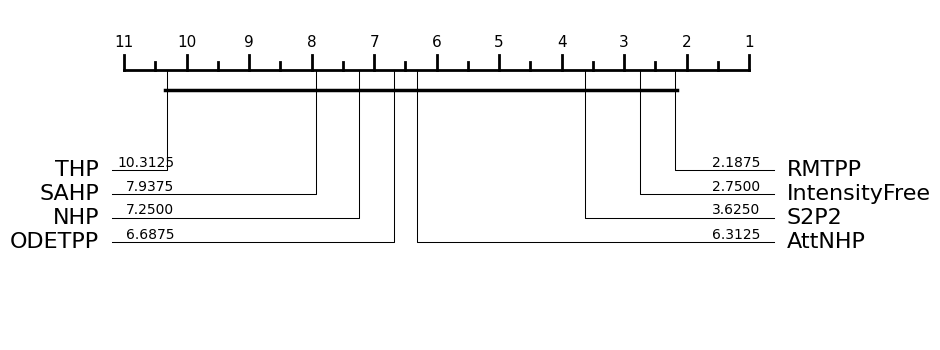

In [66]:
from math import inf

wide = df.pivot_table(
    index="dataset",
    columns="model",
    values="avg_test_acc",
    aggfunc="mean"
)
wide = wide.fillna(0, axis=0)

scores = wide.T.to_numpy()
classifiers = wide.columns.tolist()


fig, _ = plot_critical_difference(
    scores, 
    classifiers, 
    lower_better=False,
    test='wilcoxon',  # or nemenyi
    correction='holm', # or bonferroni or none
    alpha=0.01,
    width=7,
    textspace=1
)
plt.show()

# DS Ordered by each Dimension

In [65]:
wide

model,AttNHP,IntensityFree,NHP,ODETPP,RMTPP,S2P2,SAHP,THP
dataset,,,,,,,,
911,-inf,0.488165,0.561028,-inf,0.460399,0.565344,0.561125,0.561150
Overall (Norm),0.896637,0.651515,0.521517,0.892343,0.895045,0.895045,0.737646,0.893710
amazon_easytpp,0.323947,0.336707,0.329377,0.327540,0.284428,0.288878,0.318314,0.297466
earthquake,-inf,0.683572,0.683409,0.527033,0.509662,-inf,0.434678,-inf
hawkes_1,-inf,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
hawkes_dependent,0.492540,0.593737,0.591651,0.571465,0.532271,0.532028,0.593737,0.578974
human_activity,0.473958,-inf,0.481250,0.355208,0.095139,0.288542,0.137847,0.252431
mooc,-inf,0.262217,0.048395,0.007418,0.013010,-inf,-inf,-inf
retweet_easytpp,-inf,-inf,0.498160,-inf,-inf,-inf,-inf,-inf


# Correlation between Loglike and ACC/RMSE

In [13]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(db_path)

query = """
SELECT dataset, loglike, acc, rmse
FROM trials
WHERE model = 'NHP' AND fidelity = 4
"""

df = pd.read_sql_query(query, conn)
conn.close()

In [14]:
def compute_corr(group):
    return pd.Series({
        "corr_loglike_acc": group["loglike"].corr(group["acc"]),
        "corr_loglike_rmse": group["loglike"].corr(group["rmse"])
    })

corr_df = df.groupby("dataset").apply(compute_corr).reset_index()
corr_df

/software/util/JupyterLab/barnard/share/scipy/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/software/util/JupyterLab/barnard/share/scipy/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_232766/62849945.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_df = df.groupby("dataset").apply(compute_corr).reset_index()


,dataset,corr_loglike_acc,corr_loglike_rmse
0,911,-0.355872,0.078705
1,amazon_easytpp,0.673307,0.991816
2,crypto_transactions,0.962285,0.847411
3,earthquake,0.944157,-0.740206
4,hawkes_1,NaN,0.885701
5,hawkes_dependent,-0.848202,0.786741
6,human_activity,0.709074,0.377036
7,memetrack,-0.142007,0.640567
8,mooc,0.859691,-0.495714
9,retweet_easytpp,-0.315905,-0.702033


In [12]:
avg_corr = corr_df[[
    "corr_loglike_acc",
    "corr_loglike_rmse"
]].mean()

avg_row = pd.DataFrame([{
    "dataset": "AVG",
    "corr_loglike_acc": avg_corr["corr_loglike_acc"],
    "corr_loglike_rmse": avg_corr["corr_loglike_rmse"]
}])
final_df = pd.concat([corr_df, avg_row], ignore_index=True)
final_df

,dataset,corr_loglike_acc,corr_loglike_rmse
0,911,-0.468656,-0.990089
1,amazon_easytpp,0.013678,-0.982776
2,crypto_transactions,0.424915,0.986704
3,earthquake,0.835766,0.240884
4,hawkes_1,NaN,0.844473
5,hawkes_dependent,-0.839099,-0.097936
6,human_activity,0.893957,-0.946707
7,mooc,NaN,NaN
8,retweet_easytpp,-0.017643,-0.884098
9,spiketrains,1.000000,-1.000000


# Compute

In [3]:
test_sizes = {
    "synthea": 433624 // 10,
    "crypto_transactions": 20832338 // 10,
    "earthquake": 91584 // 10,
    "volcano_easytpp": 8840 // 10,
    "taxi_easytpp": 74078 // 10,
    "taxi_nyc_neighborhoods": 62089613 // 10,
    "stackoverflow": 4361540 // 10,
    "retweet_easytpp": 2610102 // 10,
    "memetrac": 28611897 // 10,
    "wikipedia": 5920802 // 10,
    "amazon_easytpp": 413420 // 10,
    "taobao_easytpp": 113410 // 10,
    "human_activity": 6449 // 10,
    "mooc": 411749 // 10,
    "spiketrains": 842941 // 10,
    "911": 663522 // 10,
    "hawkes_1": 613058 // 10,
    "hawkes_dependent": 100829 // 10,
}

conn = sqlite3.connect(db_path)

df = pd.read_sql_query("""
SELECT model, dataset, inference_duration
FROM final_results
""", conn)

conn.close()
df

,model,dataset,inference_duration
0,NHP,human_activity,2.117833
1,NHP,human_activity,1.966047
2,NHP,human_activity,2.176756
3,NHP,human_activity,1.850302
4,NHP,human_activity,1.991766
...,...,...,...
75,NHP,mooc,10.090040
76,NHP,mooc,10.849951
77,NHP,mooc,9.790494
78,THP,taxi_nyc_neighborhoods,274.392547


In [6]:
def to_ms_per_sample(row):
    test_n = test_sizes[row["dataset"]]
    return (row["inference_duration"] * 1000) / test_n

df["ms_per_sample"] = df.apply(to_ms_per_sample, axis=1)

result = (
    df.groupby(["model", "dataset"])["ms_per_sample"]
    .mean()
    .reset_index()
    .sort_values("ms_per_sample")
)

result

,model,dataset,ms_per_sample
8,THP,retweet_easytpp,0.013963
9,THP,spiketrains,0.021715
10,THP,stackoverflow,0.029977
7,THP,mooc,0.043394
3,NHP,hawkes_1,0.043522
14,THP,taxi_nyc_neighborhoods,0.044460
11,THP,synthea,0.058824
12,THP,taobao_easytpp,0.152854
1,NHP,amazon_easytpp,0.177980
0,NHP,911,0.226089
